# Experiment 3: Algorithmic Search and Grover's Algorithm

## 1. Introduction and Motivation
If you want to find a specific item in an unsorted database of $N$ items, a classical computer must check every item one by one. In the worst case, this takes $O(N)$ operations. 

In 1996, Lov Grover introduced a quantum algorithm that performs this search in $O(\sqrt{N})$ operations. For a database of 1 million items, a classical computer takes up to 1,000,000 steps; a quantum computer takes 1,000. This quadratic speedup is one of the most famous examples of **Quantum Advantage**.

However, "database search" is a poor metaphor. A better way to understand Grover's Algorithm is as a **Constraint Satisfiability Solver**. It can instantly identify the solution to a complex logic puzzle by processing all possible answers simultaneously in superposition.

## 2. The Goal of this Experiment
We will use Grover's Algorithm to solve a **Graph Coloring Problem**. 
1. We will define a square graph with 4 nodes ($A, B, C, D$) and 2 available colors ($0$ and $1$). 
2. The constraint: No two connected nodes can share the same color. 
3. We will build an **Oracle** that flags the correct answers, and a **Diffuser** that amplifies their probability.
4. We will decompose Qiskit's abstract layers to see the actual quantum logic gates operating under the hood.

## 3. The Theoretical Framework
The algorithm relies on two opposing quantum forces:
* **Phase Inversion (The Oracle):** We create a massive superposition of all 16 possible color combinations. The Oracle is a quantum circuit that recognizes the correct combinations and flips their quantum wave upside down (multiplies their phase by $-1$).
* **Inversion About the Mean (The Diffuser):** This circuit acts like a mathematical wave pool. It calculates the average amplitude of all states. Because the correct answers are now negative, the average drops. The Diffuser then reflects all amplitudes across this new average. This causes the wrong answers to destructively interfere (shrink to $0$) and the correct answers to constructively interfere (grow to $100\%$).

In [1]:
# =====================================================================
# IMPORTS AND ENVIRONMENT SETUP
# We import Qiskit's algorithm libraries and visualization tools.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseOracle, GroverOperator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import qasm2
from qiskit import transpile

simulator = AerSimulator()

## 4. The Puzzle Master (Defining the Oracle)
Imagine a square graph. Node A connects to Node B, B to C, C to D, and D back to A.
We have two colors, represented by binary bits: `0` and `1`.

We can enforce the rule "connected nodes must have different colors" using the logical XOR operator (`^`). The expression `A ^ B` is only True if A and B are different. 

To win, all four edges must be satisfied simultaneously, so we combine them with the logical AND operator (`&`).

**Winning Logic:** `(a ^ b) & (b ^ c) & (c ^ d) & (d ^ a)`

We will use Qiskit's `PhaseOracle` to translate this boolean string into a quantum circuit. Then, we will decompose it to see how a quantum computer mathematically processes boolean logic using reversible gates.

/tmp/ipykernel_143383/2883127568.py:11: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle(winning_logic)


### The Unrolled Oracle Circuit

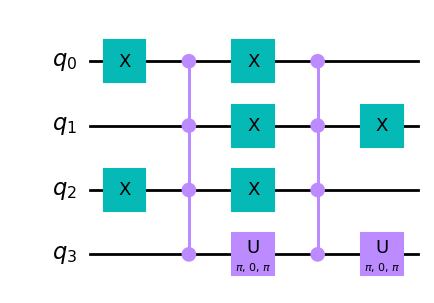

In [2]:
# =====================================================================
# THE ORACLE AND CIRCUIT DECOMPOSITION
# We translate human-readable boolean logic into a quantum phase flip,
# and then peer under the abstraction to see the native gates.
# =====================================================================

# 1. Define the boolean constraints
winning_logic = "(a ^ b) & (b ^ c) & (c ^ d) & (d ^ a)"

# 2. Let Qiskit build the abstract Oracle
oracle = PhaseOracle(winning_logic)

# 3. Expose the underlying machinery using .decompose()
# Qiskit builds logic using standard X (NOT) gates and multi-controlled
# X gates (CCX / Toffoli gates). It uses auxiliary qubits (workspace)
# to store the intermediate results of the XOR and AND operations.
decomposed_oracle = oracle.decompose()

display(Markdown("### The Unrolled Oracle Circuit"))
display(decomposed_oracle.draw('mpl', style='clifford'))

## 5. The Quantum Solver (Grover Operator)
The Oracle only flips the phase (the sign) of the correct answer. But if we measure the qubits now, the probability of finding the correct answer hasn't changed. We need the **Diffuser** to amplify that negative phase into a massive positive probability.

The combination of the Oracle + Diffuser is called the `GroverOperator`.

**How many times do we apply it?**
Mathematically, the optimal number of iterations is $\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \rfloor$, where $N$ is total possibilities ($2^4 = 16$) and $M$ is the number of valid solutions (we expect 2 valid colorings: `0101` and `1010`). 
$\lfloor \frac{\pi}{4} \sqrt{\frac{16}{2}} \rfloor \approx 2.22$. 

So, we will apply the Grover Operator exactly **2 times**. We will unroll the circuit slightly so you can see the distinct Oracle and Diffuser blocks.

/tmp/ipykernel_143383/3995136361.py:8: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover_op = GroverOperator(oracle)


### The Top-Level Search Algorithm

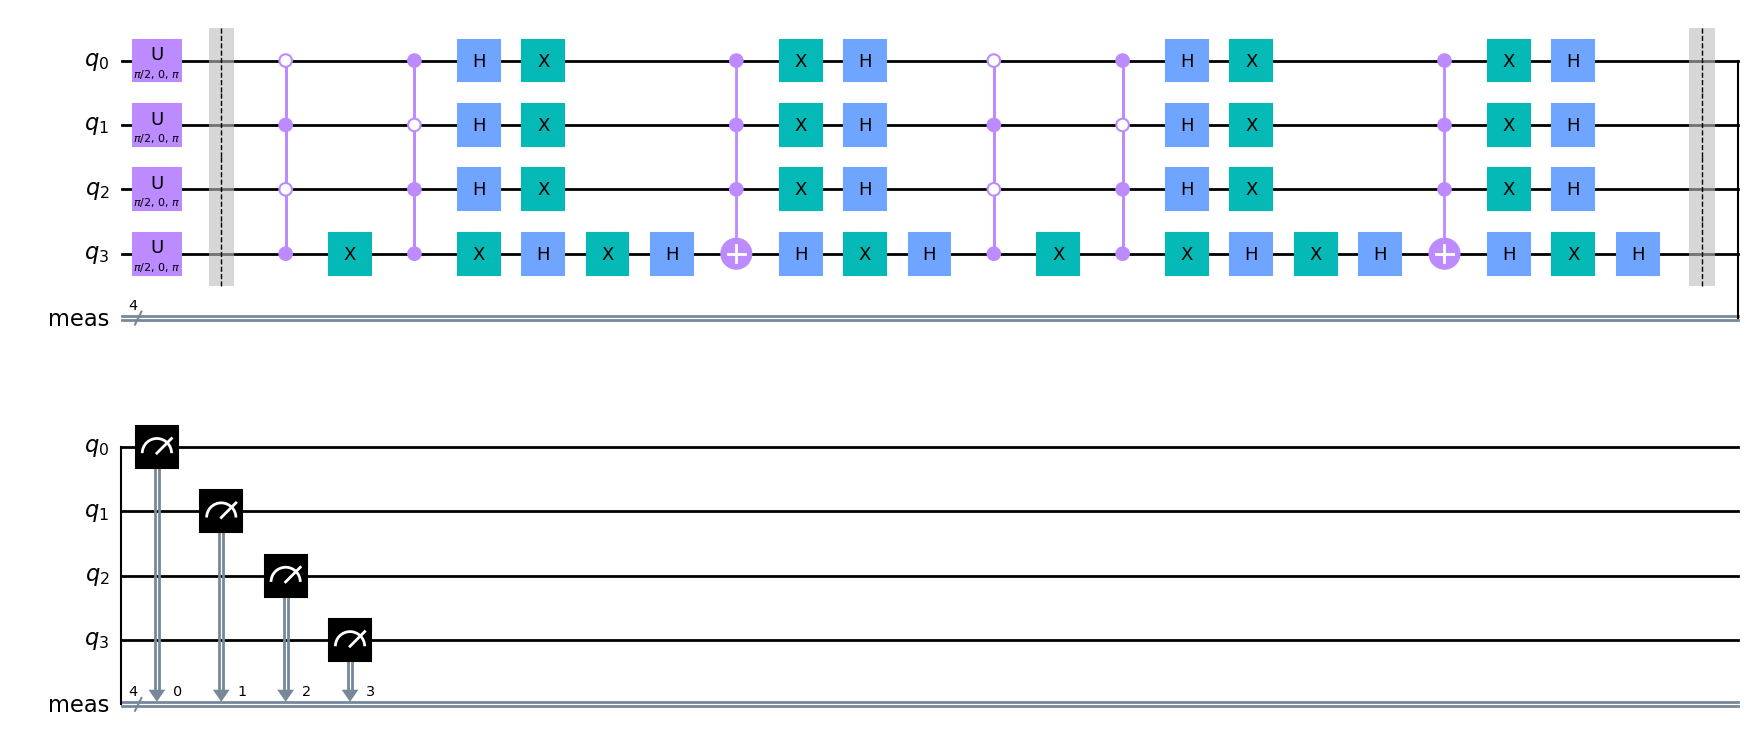

In [3]:
# =====================================================================
# ASSEMBLING THE SEARCH ENGINE
# We initialize the superposition, apply the Grover Operator twice,
# and prepare the qubits for measurement.
# =====================================================================

# Build the combined Oracle + Diffuser block
grover_op = GroverOperator(oracle)

# Initialize a circuit with 4 qubits for our 4 nodes
qc = QuantumCircuit(4)

# Step 1: Create a perfectly even superposition of all 16 color combinations
qc.h(range(4))
qc.barrier()

# Step 2: Apply the Grover Operator 2 times
qc.compose(grover_op, inplace=True)
qc.compose(grover_op, inplace=True)

# Step 3: Measure the result
qc.measure_all()

# Decomposing the circuit once (reps=1) removes the opaque "GroverOperator"
# box and reveals the distinct "Oracle" and "Diffuser" sub-blocks.
display(Markdown("### The Top-Level Search Algorithm"))
display(qc.decompose(reps=1).draw('mpl', style='clifford'))

## 6. Execution and Amplification Verification
We will now run the search engine on our simulator. We will execute it 10,000 times to get a very clear probability distribution.

If the algorithm works, the destructive interference will have crushed the probability of measuring any of the 14 incorrect color combinations, and the constructive interference will cause the 2 correct answers to tower above the rest.

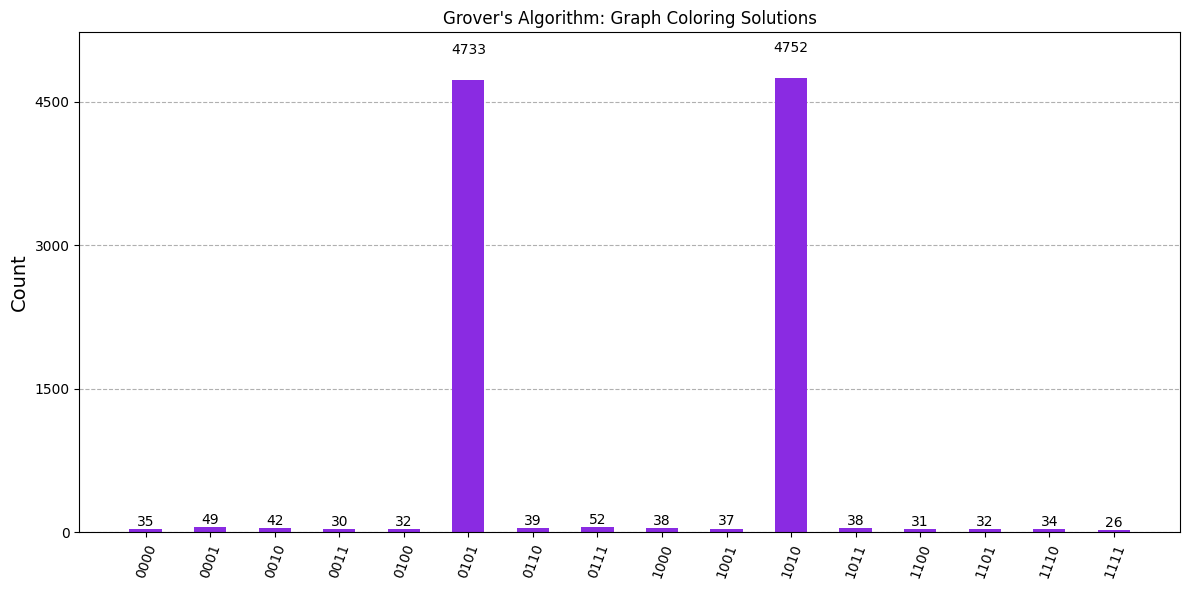

### 🎯 Expected Solutions
Node colors (D C B A) should alternate. **Valid answers: `0101` and `1010`**

### 📊 Measured Results
- **State $|1010\rangle$**: measured 4752 times (47.5%)
- **State $|0101\rangle$**: measured 4733 times (47.3%)


In [4]:
# =========================================================================
# SIMULATION AND VISUALIZATION
# We transpile the circuit into native gates, execute it 10,000 times, and
# plot the resulting probability distribution of the 16 possible states.
# =========================================================================

NUM_SHOTS = 10000

# The AerSimulator does not natively understand the abstract "Q" (Grover)
# instruction. We must transpile (compile) the circuit into standard
# fundamental gates that the simulator can actually execute.
transpiled_qc = transpile(qc, simulator)

# Run the search
job = simulator.run(transpiled_qc, shots=NUM_SHOTS)
results = job.result()
counts = results.get_counts()

# Plot the results
display(plot_histogram(counts, figsize=(12, 6), title="Grover's Algorithm: Graph Coloring Solutions", color='#8A2BE2'))

# Print the explicit findings
results_text = "### 🎯 Expected Solutions\n"
results_text += "Node colors (D C B A) should alternate. **Valid answers: `0101` and `1010`**\n\n"
results_text += "### 📊 Measured Results\n"

for state, count in counts.items():
    if count > (NUM_SHOTS / 16):
        results_text += f"- **State $|{state}\\rangle$**: measured {count} times ({(count/NUM_SHOTS)*100:.1f}%)\n"

display(Markdown(results_text))

## 7. Conclusion
The experiment effectively demonstrates algorithmic quantum speedup and interference logic.

1.  **Constraint Solved:** Out of 16 possible states, the algorithm successfully isolated `0101` and `1010` with near 100% certainty. (Note: Qiskit reads strings right-to-left, so `0101` means A=1, B=0, C=1, D=0. This perfectly satisfies our "no touching nodes share a color" rule).
2.  **Quantum Hardware Abstractions:** By using `.decompose()`, we verified that high-level computer science concepts (like `XOR` and `AND` gates in an Oracle) physically compile down to networks of standard quantum gates (Hadamard, Pauli-X, and Multi-Controlled X). 
3.  **Algorithmic Efficiency:** A classical computer testing answers randomly or sequentially would need to evaluate multiple failing states. Our quantum circuit found the answers instantly using exactly 2 queries to the Oracle, capitalizing on the $O(\sqrt{N})$ optimization.

## 8. Bibliography & Further Reading

1. **Grover, L. K. (1996).** *A fast quantum mechanical algorithm for database search*. Proceedings of the 28th Annual ACM Symposium on the Theory of Computing, 212–219. [arXiv:quant-ph/9605043](https://arxiv.org/abs/quant-ph/9605043)
2. **IBM Quantum Learning:** [Grover's Algorithm](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/grovers-algorithm)
3. **Wikipedia:** [Grover's algorithm](https://en.wikipedia.org/wiki/Grover%27s_algorithm)